# ECGR 4161 — Kalman Filter Sensor Fusion Assignment

## Overview

A moving robot rarely knows its own motion for certain. Every onboard sensor
gives a *noisy* estimate of some quantity, and no single sensor tells the whole
story. In this lab you will study how a **Kalman filter** fuses three noisy
sensors into one clean, statistically-optimal estimate of the robot's motion.

The robot drives along a **circular path**. Three sensors report on its motion
every time step:

| Sensor | Measures | Symbol | Units |
|---|---|---|---|
| Wheel **encoder** | linear velocity | $v$ | m/s |
| **Accelerometer** | linear (tangential) acceleration | $a$ | m/s² |
| **Gyroscope** | rotational (yaw) velocity | $\omega$ | rad/s |

The Kalman filter maintains a belief about the robot's motion **state**

$$\mathbf{x} = \begin{bmatrix} v \\ a \\ \omega \end{bmatrix}$$

and refines that belief in two alternating steps every iteration:

1. **Predict** — push the belief forward in time using the *dynamics* of the
   robot (how velocity, acceleration, and rotation relate). **No control input
   is used** — the filter only relies on the physics model.
2. **Update (measurement)** — pull the belief toward the three sensor readings,
   weighted by how much we trust the model versus the sensors.

The Kalman filter itself is **already implemented for you**. Your job is *not*
to write the filter — it is to **experiment with the process-noise matrix `Q`
and the measurement-noise matrix `R`** and observe how those two knobs change
the way the filter blends the model prediction with the sensor data.

## What you will see

Every iteration, the notebook **pauses** and redraws a dashboard showing:

- the **circular trajectory** with a marker for the robot's current position
  (shown for context — this lab fuses motion measurements, not position),
- **time-series** plots of each variable ($v$, $a$, $\omega$): the true value,
  the noisy sensor reading, and the filter's fused estimate with its
  uncertainty band, and
- **Gaussian distributions** for each variable at the current step — the
  distribution **after prediction** (the prior), the distribution of the
  **measurement** (the sensor), and the distribution **after the update** (the
  posterior). Watching these three bells shift and sharpen is the heart of the
  lab.

## Learning Objectives

After completing this notebook, you should be able to:

1. Describe the predict/update cycle of a linear Kalman filter.
2. Explain how the process-noise `Q` and measurement-noise `R` matrices control
   the balance between trusting the motion model and trusting the sensors.
3. Read a Gaussian "belief" plot and identify the prior, the measurement
   likelihood, and the fused posterior.
4. Predict qualitatively how the estimate changes when `Q` or `R` grows or
   shrinks.
5. Relate multi-sensor fusion to a physically meaningful robot maneuver
   (driving a circle).


## Setup

Run the following cell first. It imports the libraries used by the simulation
and the live dashboard.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, clear_output

# Consistent, readable plot styling
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.alpha"] = 0.4


## The Motion Model (Prediction Dynamics)

The Kalman filter's **predict** step advances the state with a constant-time-step
linear model. With state $\mathbf{x} = [\,v,\ a,\ \omega\,]^{\mathsf T}$ and time
step $\Delta t$:

$$
\begin{aligned}
v_{k+1}      &= v_k + a_k\,\Delta t & \text{(velocity integrates acceleration)}\\
a_{k+1}      &= a_k                 & \text{(acceleration assumed steady)}\\
\omega_{k+1} &= \omega_k            & \text{(turn rate assumed steady)}
\end{aligned}
$$

In matrix form $\mathbf{x}_{k+1} = F\,\mathbf{x}_k$ (there is **no** $B\mathbf{u}$
control term):

$$
F = \begin{bmatrix} 1 & \Delta t & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

Because the true robot *does* change its acceleration and turn rate (when it
speeds up and slows down), the constant-$a$ / constant-$\omega$ assumption is
imperfect. The **process-noise matrix `Q`** tells the filter how much to distrust
this idealized model.

## The Measurement Model

All three sensors observe state variables directly, so the measurement matrix
$H$ is the identity:

$$
\mathbf{z} = H\,\mathbf{x} + \text{noise}, \qquad
H = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

The **measurement-noise matrix `R`** encodes how noisy each sensor is. A large
diagonal entry means "this sensor is unreliable — don't move the estimate far
toward it."


## Step 1 — Generate the True Robot Trajectory

We first create a *ground-truth* motion profile for a robot driving a circle of
fixed radius. The robot accelerates from rest, cruises at constant speed, then
decelerates back to rest. Because it follows a circle, its turn rate is
$\omega = v / R$, so the gyroscope sees a real, changing rotational velocity.

You do not need to modify this cell.


In [2]:
# ── Simulation constants ───────────────────────────────────────────────────
DT = 0.2            # time step (s)
RADIUS = 5.0        # radius of the circular path (m)


def generate_truth(dt=DT, radius=RADIUS):
    """Return ground-truth arrays for a robot driving a circle.

    Returns
    -------
    t      : time stamps (s)
    v      : linear velocity (m/s)
    a      : tangential acceleration (m/s^2)
    w      : rotational velocity (rad/s)  =  v / radius
    x, y   : world-frame position on the circular path (m)
    """
    accel = 0.30                 # m/s^2 during accel/decel phases
    v_cruise = 1.50              # m/s cruise speed
    t_accel = v_cruise / accel   # 5 s to reach cruise
    t_cruise = 6.0               # 6 s at cruise
    t_decel = t_accel            # symmetric decel
    total = t_accel + t_cruise + t_decel

    n = int(round(total / dt))
    t = np.arange(n) * dt
    v = np.zeros(n)
    a = np.zeros(n)

    for i, ti in enumerate(t):
        if ti < t_accel:                       # speeding up
            a[i] = accel
            v[i] = accel * ti
        elif ti < t_accel + t_cruise:          # cruising
            a[i] = 0.0
            v[i] = v_cruise
        else:                                  # slowing down
            a[i] = -accel
            v[i] = v_cruise - accel * (ti - (t_accel + t_cruise))

    v = np.clip(v, 0.0, None)
    w = v / radius                             # circular-path turn rate

    # Integrate heading and position to trace the path.
    x = np.zeros(n)
    y = np.zeros(n)
    theta = 0.0
    px = py = 0.0
    for i in range(n):
        x[i], y[i] = px, py
        px += v[i] * np.cos(theta) * dt
        py += v[i] * np.sin(theta) * dt
        theta += w[i] * dt

    return t, v, a, w, x, y


t_true, v_true, a_true, w_true, x_true, y_true = generate_truth()
N_STEPS = len(t_true)
print(f"Generated {N_STEPS} time steps over {t_true[-1] + DT:.1f} s "
      f"(dt = {DT} s, radius = {RADIUS} m).")


Generated 80 time steps over 16.0 s (dt = 0.2 s, radius = 5.0 m).


## Step 2 — Add Sensor Noise

Real sensors are noisy. We create the encoder, accelerometer, and gyroscope
readings by adding zero-mean Gaussian noise to the true values. The noise
standard deviations below describe how good each sensor is.

You do not need to modify this cell — but notice these `SIGMA_*` values, because
a well-chosen `R` matrix later should roughly match them.


In [3]:
# ── True sensor noise levels (standard deviations) ─────────────────────────
SIGMA_ENC = 0.10    # encoder velocity noise      (m/s)
SIGMA_ACC = 0.25    # accelerometer noise         (m/s^2)
SIGMA_GYRO = 0.04   # gyroscope noise             (rad/s)

np.random.seed(0)   # fixed seed => everyone sees the same measurements

z_v = v_true + np.random.normal(0.0, SIGMA_ENC, size=N_STEPS)   # encoder
z_a = a_true + np.random.normal(0.0, SIGMA_ACC, size=N_STEPS)   # accelerometer
z_w = w_true + np.random.normal(0.0, SIGMA_GYRO, size=N_STEPS)  # gyroscope

# Stack into a (N_STEPS x 3) array of measurement vectors [v, a, w].
Z = np.column_stack([z_v, z_a, z_w])
print("Measurement array shape:", Z.shape)


Measurement array shape: (80, 3)


## Step 3 — The Kalman Filter (Provided — do not modify)

This is a standard linear Kalman filter. Read it so you understand what `Q` and
`R` do, but **you do not need to change any of this code**.

Each call to `predict()` stores the **prior** (`x_pred`, `P_pred`) — the belief
*after* the dynamics step. Each call to `update(z)` produces the **posterior**
(`x`, `P`) — the belief *after* folding in the measurement. Both are saved so the
dashboard can draw the Gaussian "before/after" bells for every variable.


In [4]:
class KalmanFilter:
    """Textbook linear Kalman filter with no control input.

    State evolves as  x_{k+1} = F x_k + process_noise(Q)
    Measurements are  z_k     = H x_k + measurement_noise(R)
    """

    def __init__(self, F, H, Q, R, x0, P0):
        self.F = np.asarray(F, dtype=float)   # state-transition (dynamics)
        self.H = np.asarray(H, dtype=float)   # measurement model
        self.Q = np.asarray(Q, dtype=float)   # process-noise covariance
        self.R = np.asarray(R, dtype=float)   # measurement-noise covariance
        self.x = np.asarray(x0, dtype=float)  # current state estimate
        self.P = np.asarray(P0, dtype=float)  # current estimate covariance

        # Snapshots of the most recent prediction (the "prior").
        self.x_pred = self.x.copy()
        self.P_pred = self.P.copy()

    def predict(self):
        """Advance the belief with the dynamics model (no control input)."""
        self.x_pred = self.F @ self.x
        self.P_pred = self.F @ self.P @ self.F.T + self.Q
        # The prior becomes the current belief until an update arrives.
        self.x = self.x_pred.copy()
        self.P = self.P_pred.copy()
        return self.x_pred, self.P_pred

    def update(self, z):
        """Fold a measurement z into the belief (the measurement step)."""
        z = np.asarray(z, dtype=float)
        y = z - self.H @ self.x_pred                     # innovation
        S = self.H @ self.P_pred @ self.H.T + self.R     # innovation covariance
        K = self.P_pred @ self.H.T @ np.linalg.inv(S)    # Kalman gain
        self.x = self.x_pred + K @ y                     # posterior mean
        I = np.eye(self.P_pred.shape[0])
        self.P = (I - K @ self.H) @ self.P_pred          # posterior covariance
        return self.x, self.P


## Step 4 — Tune `Q` and `R` (This is your experiment!)

This is the cell you will change. `Q` and `R` are the only two knobs you tune.

- **`R` (measurement noise)** — how much the filter *distrusts the sensors*.
  - Small `R` → "the sensors are accurate" → estimate hugs the noisy readings.
  - Large `R` → "the sensors are unreliable" → estimate leans on the model and
    stays smooth (but can lag).
- **`Q` (process noise)** — how much the filter *distrusts its own model*.
  - Small `Q` → "the model is nearly perfect" → estimate is smooth and slow to
    react to change.
  - Large `Q` → "the model is rough" → estimate reacts quickly to the sensors.

A sensible starting point sets `R` to the *true* sensor variances (the squares of
the `SIGMA_*` values). Start there, run the dashboard, then come back and try the
suggested experiments in Step 6.

The state ordering is always `[v, a, w]`.


In [5]:
# Time step baked into the dynamics matrix.
F = np.array([
    [1.0, DT,  0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
])

# Sensors observe the state directly => H is the identity.
H = np.eye(3)

# ======================================================================
# EXPERIMENT ZONE — change Q and R and re-run the dashboard (Step 5).
# ======================================================================

# Process-noise covariance Q: how much we distrust the constant-a / constant-w
# motion model. Larger values let the estimate react faster to the sensors.
Q = np.diag([
    0.01,   # velocity      process noise
    0.05,   # acceleration  process noise
    0.005,  # turn-rate     process noise
])

# Measurement-noise covariance R: how noisy we BELIEVE each sensor is.
# A good starting guess is the true sensor variance (SIGMA ** 2).
R = np.diag([
    SIGMA_ENC ** 2,    # encoder       variance
    SIGMA_ACC ** 2,    # accelerometer variance
    SIGMA_GYRO ** 2,   # gyroscope     variance
])

# ======================================================================

# Initial belief: start unsure (large P0) so the filter locks on quickly.
x0 = np.array([0.0, 0.0, 0.0])
P0 = np.diag([1.0, 1.0, 1.0])

print("Q =\n", Q)
print("R =\n", R)


Q =
 [[0.01  0.    0.   ]
 [0.    0.05  0.   ]
 [0.    0.    0.005]]
R =
 [[0.01   0.     0.    ]
 [0.     0.0625 0.    ]
 [0.     0.     0.0016]]


## Step 5 — Run the Live Fusion Dashboard

Run the cell below. It steps the Kalman filter through the whole trajectory,
**pausing after every iteration** to redraw the dashboard:

- **Top:** the true circular path with a marker showing where the robot is right
  now. (This lab is about *fusing motion measurements*, not localization, so no
  estimated position is drawn.)
- **Middle row:** time-series for velocity, acceleration, and turn rate. Gray =
  truth, faint dots = noisy sensor, blue = fused estimate with a ±1σ uncertainty
  band.
- **Bottom row:** the Gaussian beliefs for each variable *at the current step* —
  the orange **prediction** (prior), the green **measurement** (sensor), and the
  blue **updated** (posterior) distribution. The posterior is always narrower
  than either input: that sharpening *is* the fusion.

Set `PAUSE` smaller to speed things up, or `RENDER_EVERY` larger to draw fewer
frames. The filter still processes every measurement regardless.


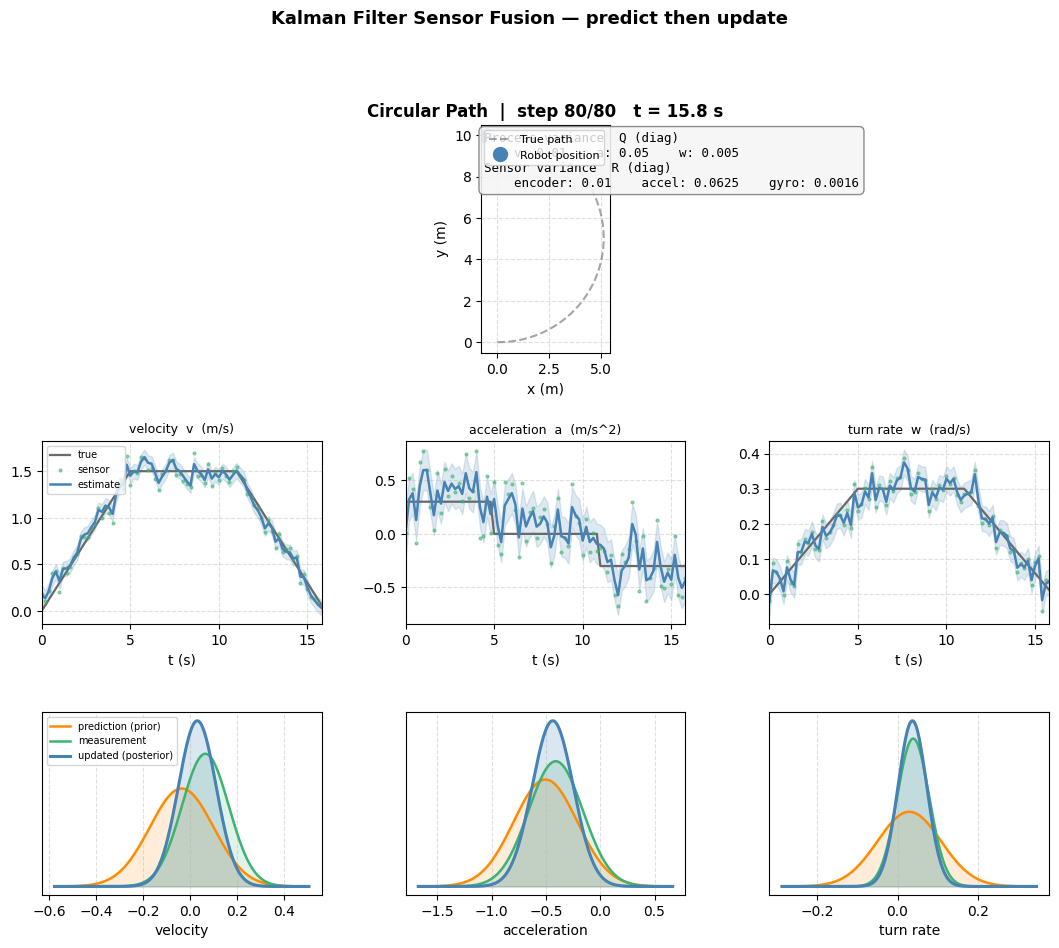

RMSE vs. truth  ->  v: 0.0760 m/s   a: 0.1672 m/s^2   w: 0.0313 rad/s


In [ ]:
PAUSE = 0.20        # seconds to pause between rendered frames
RENDER_EVERY = 1    # draw every Nth step (filter still runs every step)


def gaussian_pdf(x, mu, sigma):
    """Evaluate a 1-D Gaussian pdf (sigma floored to stay numerically safe)."""
    sigma = max(float(sigma), 1e-9)
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def run_fusion(Q, R, pause=PAUSE, render_every=RENDER_EVERY):
    """Run the Kalman filter over the trajectory with a live dashboard."""
    kf = KalmanFilter(F, H, Q, R, x0, P0)

    labels = ["velocity  v  (m/s)", "acceleration  a  (m/s^2)", "turn rate  w  (rad/s)"]
    truth_series = [v_true, a_true, w_true]

    # Histories for the time-series plots.
    est_mean = np.zeros((N_STEPS, 3))
    est_std = np.zeros((N_STEPS, 3))

    # Text summaries of the tuning knobs (constant for the whole run).
    q_diag = np.diag(Q)
    r_diag = np.diag(R)
    proc_text = (
        "PREDICTION STEP\n"
        "process variance  Q\n"
        "─────────────────\n"
        f"v :  {q_diag[0]:.4g}\n"
        f"a :  {q_diag[1]:.4g}\n"
        f"w :  {q_diag[2]:.4g}"
    )
    sensor_text = (
        "MEASUREMENT STEP\n"
        "sensor variance  R\n"
        "──────────────────\n"
        f"encoder :  {r_diag[0]:.4g}\n"
        f"accel   :  {r_diag[1]:.4g}\n"
        f"gyro    :  {r_diag[2]:.4g}"
    )

    for k in range(N_STEPS):
        # 1) PREDICT  -> prior (distribution "after prediction")
        x_pred, P_pred = kf.predict()
        # 2) UPDATE   -> posterior (distribution "after the measurement step")
        z = Z[k]
        x_upd, P_upd = kf.update(z)

        est_mean[k] = x_upd
        est_std[k] = np.sqrt(np.diag(P_upd))

        if (k % render_every) != 0 and k != N_STEPS - 1:
            continue

        # ── Draw the dashboard ────────────────────────────────────────────
        fig = plt.figure(figsize=(13, 10))
        gs = gridspec.GridSpec(3, 3, height_ratios=[1.25, 1.0, 1.0],
                               hspace=0.45, wspace=0.30)

        # Top-left: process (prediction) variances.
        ax_left = fig.add_subplot(gs[0, 0])
        ax_left.axis("off")
        ax_left.text(
            0.95, 0.5, proc_text, transform=ax_left.transAxes,
            fontsize=11, family="monospace", va="center", ha="right",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff3e6",
                      edgecolor="darkorange", linewidth=1.5))

        # Top-center: the true circular path with the robot's current position.
        ax_traj = fig.add_subplot(gs[0, 1])
        ax_traj.plot(x_true, y_true, "--", color="dimgray", lw=1.5,
                     alpha=0.6, label="True path")
        ax_traj.plot(x_true[k], y_true[k], "o", color="steelblue", ms=10,
                     label="Robot position")
        ax_traj.set_aspect("equal")
        ax_traj.set_xlabel("x (m)")
        ax_traj.set_ylabel("y (m)")
        ax_traj.legend(loc="upper right", fontsize=8)
        ax_traj.set_title(
            f"Circular Path  |  step {k + 1}/{N_STEPS}   t = {t_true[k]:.1f} s",
            fontsize=12, weight="bold")

        # Top-right: sensor (measurement) variances.
        ax_right = fig.add_subplot(gs[0, 2])
        ax_right.axis("off")
        ax_right.text(
            0.05, 0.5, sensor_text, transform=ax_right.transAxes,
            fontsize=11, family="monospace", va="center", ha="left",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#ecf7ef",
                      edgecolor="mediumseagreen", linewidth=1.5))

        colors_ts = ("dimgray", "mediumseagreen", "steelblue")
        for i in range(3):
            # Middle row: time series.
            ax_ts = fig.add_subplot(gs[1, i])
            ax_ts.plot(t_true[:k + 1], truth_series[i][:k + 1], "-",
                       color="dimgray", lw=1.6, label="true")
            ax_ts.plot(t_true[:k + 1], Z[:k + 1, i], ".", color="mediumseagreen",
                       ms=4, alpha=0.55, label="sensor")
            ax_ts.plot(t_true[:k + 1], est_mean[:k + 1, i], "-",
                       color="steelblue", lw=1.8, label="estimate")
            ax_ts.fill_between(
                t_true[:k + 1],
                est_mean[:k + 1, i] - est_std[:k + 1, i],
                est_mean[:k + 1, i] + est_std[:k + 1, i],
                color="steelblue", alpha=0.18)
            ax_ts.set_xlim(t_true[0], t_true[-1])
            ax_ts.set_xlabel("t (s)")
            ax_ts.set_title(labels[i], fontsize=9)
            if i == 0:
                ax_ts.legend(loc="upper left", fontsize=7)

            # Bottom row: Gaussian beliefs at this step.
            ax_g = fig.add_subplot(gs[2, i])
            mu_pred, sd_pred = x_pred[i], np.sqrt(P_pred[i, i])
            mu_meas, sd_meas = z[i], np.sqrt(R[i, i])
            mu_post, sd_post = x_upd[i], np.sqrt(P_upd[i, i])

            lo = min(mu_pred - 4 * sd_pred, mu_meas - 4 * sd_meas,
                     mu_post - 4 * sd_post)
            hi = max(mu_pred + 4 * sd_pred, mu_meas + 4 * sd_meas,
                     mu_post + 4 * sd_post)
            xs = np.linspace(lo, hi, 300)

            ax_g.plot(xs, gaussian_pdf(xs, mu_pred, sd_pred), color="darkorange",
                      lw=1.8, label="prediction (prior)")
            ax_g.fill_between(xs, gaussian_pdf(xs, mu_pred, sd_pred),
                              color="darkorange", alpha=0.15)
            ax_g.plot(xs, gaussian_pdf(xs, mu_meas, sd_meas),
                      color="mediumseagreen", lw=1.8, label="measurement")
            ax_g.fill_between(xs, gaussian_pdf(xs, mu_meas, sd_meas),
                              color="mediumseagreen", alpha=0.15)
            ax_g.plot(xs, gaussian_pdf(xs, mu_post, sd_post), color="steelblue",
                      lw=2.2, label="updated (posterior)")
            ax_g.fill_between(xs, gaussian_pdf(xs, mu_post, sd_post),
                              color="steelblue", alpha=0.20)
            ax_g.set_yticks([])
            ax_g.set_xlabel(labels[i].split("  ")[0])
            if i == 0:
                ax_g.legend(loc="upper left", fontsize=7)

        fig.suptitle("Kalman Filter Sensor Fusion — predict then update",
                     fontsize=13, weight="bold", y=0.995)

        clear_output(wait=True)
        plt.show()
        time.sleep(pause)
        plt.close(fig)

    # Report fused-estimate accuracy.
    rmse = np.sqrt(np.mean((est_mean - np.column_stack(truth_series)) ** 2, axis=0))
    print("RMSE vs. truth  ->  "
          f"v: {rmse[0]:.4f} m/s   a: {rmse[1]:.4f} m/s^2   w: {rmse[2]:.4f} rad/s")
    return est_mean, est_std, rmse


_ = run_fusion(Q, R)


## Step 6 — Experiments

Change `Q` and/or `R` in **Step 4**, re-run Step 4, then re-run Step 5. For each
experiment below, watch both the **time-series** (does the blue estimate hug the
noisy dots or the smooth truth?) and the **Gaussian beliefs** (which bell is
narrow, which is wide, where does the posterior land?). The printed **RMSE** lets
you compare runs numerically.

| # | Change | What to look for |
|---|---|---|
| 1 | **Trust the sensors:** shrink `R` by 100× (`R * 0.01`) | Estimate snaps onto the noisy dots; posterior bell nearly matches the measurement bell. RMSE for a/ω usually rises. |
| 2 | **Distrust the sensors:** grow `R` by 100× (`R * 100`) | Estimate becomes very smooth but lags during accel/decel; posterior barely moves off the prediction bell. |
| 3 | **Trust the model:** shrink `Q` by 100× | Very smooth estimate, slow to react when acceleration jumps; big lag at the phase changes. |
| 4 | **Distrust the model:** grow `Q` by 100× | Estimate reacts fast but gets noisy; posterior leans toward the measurement. |
| 5 | **Mismatched sensor trust:** make only `R[1,1]` (accelerometer) huge | Watch how the filter leans on the *encoder* and the model to reconstruct acceleration instead of the noisy accelerometer. |

Use the cell below as a scratchpad to run a single experiment without editing
Step 4 (it builds fresh `Q`/`R` locally and calls `run_fusion`).


In [ ]:
# Scratchpad experiment — edit the multipliers and run this cell.
Q_exp = Q.copy() * 1.0     # try * 100 or * 0.01
R_exp = R.copy() * 1.0     # try * 100 or * 0.01

# Example for experiment #5 (uncomment to distrust ONLY the accelerometer):
# R_exp = R.copy()
# R_exp[1, 1] *= 1000.0

_ = run_fusion(Q_exp, R_exp)


## Reflection Questions

Answer these in a few sentences each based on what you observed. There is no
"self-check" for this lab — the goal is understanding, not a matching score.

1. When you **shrank `R`**, did the fused estimate get closer to the true values
   or closer to the noisy sensor readings? Explain using the Gaussian plots.
2. When you **grew `Q`**, how did the width of the *prediction* Gaussian change,
   and why did that let the estimate react faster to changes in the truth?
3. During the acceleration and deceleration phases, the constant-$\omega$ model
   is wrong (the true turn rate is changing). Which setting of `Q` handled these
   phase changes best, and why?
4. The posterior (updated) Gaussian is always **narrower** than both the
   prediction and the measurement Gaussians. In your own words, why does fusing
   two noisy sources produce a *more* certain estimate?
5. Suppose you swapped in a much better gyroscope (tiny `SIGMA_GYRO`). How should
   you change `R` to take advantage of it, and what would you expect to happen to
   the turn-rate estimate?

## How to Submit

Follow the instructions on the Canvas assignment page. You will typically submit
your final `Q` and `R` matrices along with written answers to the reflection
questions above and a brief note on which settings gave the lowest RMSE.
